In [ ]:
from pettingzoo.classic import chess_v6
import matplotlib.pyplot as plt
import chess

pieces= {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
}

/Users/michal.zareba/miza-repos/chessengine/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [49]:
import gymnasium as gym
import numpy as np
import torch
from pettingzoo.classic import chess_v6
from pettingzoo.utils.conversions import turn_based_aec_to_parallel_wrapper
from stable_baselines3.common.vec_env import SubprocVecEnv


# --- 1. The Explicit Gymnasium Wrapper ---
class SB3ChessWrapper(gym.Env):
    """
    A true Gymnasium wrapper for PettingZoo Chess.
    Inheriting from gym.Env fixes the AssertionError.
    """

    metadata = {"render_modes": ["human"], "name": "chess_v6"}

    def __init__(self):
        super().__init__()
        # 1. Create the internal PettingZoo environment
        env = chess_v6.env()
        env.metadata["is_parallelizable"] = True
        self.env = turn_based_aec_to_parallel_wrapper(env)

        # 2. Define spaces based on the first agent (White)
        # SB3 needs these to be actual Gymnasium space objects
        self.observation_space = self.env.observation_space(self.env.possible_agents[0])
        self.action_space = self.env.action_space(self.env.possible_agents[0])

        self.agents = self.env.possible_agents
        self.curr_obs = None

    def reset(self, seed=None, options=None):
        # Handle seeding for reproducibility
        obs_dict, infos = self.env.reset(seed=seed, options=options)
        # Store observation for action_masks()
        self.curr_obs = obs_dict[self.agents[0]]
        return self.curr_obs, infos[self.agents[0]]

    def step(self, action):
        # Map the single action to the active player
        # PettingZoo ParallelEnv expects a dict of actions
        actions = {agent: action for agent in self.agents}

        obs_dict, rewards, terms, truncs, infos = self.env.step(actions)

        # We always follow the perspective of the primary agent (White)
        # This is a standard 'Self-Play' simplification
        agent = self.agents[0]
        self.curr_obs = obs_dict[agent]

        return self.curr_obs, rewards[agent], terms[agent], truncs[agent], infos[agent]

    def render(self):
        return self.env.render()

    def close(self):
        self.env.close()

    def last(self):
        return self.env.last()

def make_env():
    return SB3ChessWrapper()


env = SubprocVecEnv([make_env,make_env], start_method="spawn")


/Users/michal.zareba/miza-repos/chessengine/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
/Users/michal.zareba/miza-repos/chessengine/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [15]:
import torch 
from torch import nn 
from copy import deepcopy
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return torch.relu(out)

class ChessPolicy(nn.Module):
    def __init__(self, num_res_blocks=4):
        super().__init__()
        # Initial extraction: 111 planes -> 128 filters
        self.conv_input = nn.Sequential(
            nn.Conv2d(111, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )
        
        # Residual Tower
        self.res_tower = nn.Sequential(
            *[ResBlock(128) for _ in range(num_res_blocks)]
        )
        
        # Policy Head: Reduce filters before flattening to avoid parameter explosion
        self.policy_head = nn.Sequential(
            nn.Conv2d(128, 32, kernel_size=1), # 1x1 conv to reduce depth
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 4672) # Map to action space
        )

    def forward(self, obs, mask=None):
        # obs shape: (Batch, 111, 8, 8)
        x = self.conv_input(obs)
        x = self.res_tower(x)
        logits = self.policy_head(x)
        
        if mask is not None:
            # Illegal move masking: Set logits of illegal moves to a very low value
            # mask shape: (Batch, 4672)
            logits = torch.where(mask.bool(), logits, torch.tensor(-1e9).to(logits.device))
            
        return logits


In [16]:
import numpy as np
import random
def policy(model, observation, mask, eps=0.1):
    model.eval() # Ensure BN layers don't update during inference
    with torch.no_grad():
        if random.random() < eps:
            # Exploration: Randomly pick from legal moves only
            legal_indices = np.flatnonzero(mask)
            return torch.tensor([[random.choice(legal_indices)]])
        else:
            # Exploitation: Model chooses best masked logit
            logits = model(observation, mask)
            return torch.argmax(logits, dim=1, keepdim=True)


In [17]:
def calculate_reward(board):
  if board.is_checkmate():
    return -1.0 if board.turn == chess.WHITE else 1.0
  white_value = 0
  black_value = 0
  for piece in pieces.keys():
    white_value += len(board.pieces(piece, chess.WHITE)) * pieces[piece]
    black_value += len(board.pieces(piece, chess.BLACK)) * pieces[piece]
  return (white_value - black_value) / 50.0

In [18]:
import random
class ReplayMemory:
  def __init__(self, capacity):
    self.capacity = capacity
    self.position = 0
    self.batch_size = 150
    self.memory = []

  def push(self, transition):
    if len(self.memory) < self.capacity:
      self.memory.append(None)
    self.memory[self.position] = transition
    self.position = (self.position + 1) % self.capacity

  def sample(self,batch_size):
    batch = random.sample(self.memory, batch_size)
    batch = zip(*batch)
    return [torch.cat(b) for b in batch]

  def can_sample(self):
    return len(self.memory) >= (self.batch_size * 10)



In [19]:
from torch.nn.functional import mse_loss

def training(memory,model,target_model,optimizer,batch_size):
  losses = []
  last_loss = None
  for i in range(memory.batch_size//batch_size):
    batch = memory.sample(batch_size)
    current_q = model(batch[0], batch[1]).gather(1, batch[2])
    model.train()
    with torch.no_grad():
      next_logits_online = model(batch[4], batch[5])
      next_action = torch.argmax(next_logits_online, dim=1, keepdim=True)
      next_q = target_model(batch[4], batch[5])
      max_next_q = next_q.gather(1, next_action)
      target_q = batch[3] + 0.99 * (1-batch[6]) * max_next_q
      for i in range(len(batch[3])):
        if batch[6][i] == 1:
          print("Game with final reward:", batch[3][i], " won by", env.unwrapped.board.result(), "target:", target_q[i], "done:", batch[6][i])
    loss = mse_loss(current_q, target_q)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    last_loss = float(loss.detach())
    losses.append(last_loss)
    return losses
    

In [20]:
import chess
import chess.engine
from pettingzoo.classic.chess import chess_utils
engine = chess.engine.SimpleEngine.popen_uci("stockfish")  # or full path
engine.configure({"Skill Level": 10})
def play_engine_move(env):
  result = engine.play(env.unwrapped.board, chess.engine.Limit(time=0.05))
  move = result.move 
  move_for_mapping = chess_utils.mirror_move(move) if env.unwrapped.board.turn == chess.BLACK else move
  uci = move_for_mapping.uci()
  if uci not in chess_utils.moves_to_actions:
    chess_utils.make_move_mapping(uci)
  return chess_utils.moves_to_actions[uci]

In [21]:
def create_states(env, obs_torch_white, action_mask_white, action_white, done, memory_white, old_reward):
  new_observation, done,_,_,_ = env.last()
  new_obs_torch_white = torch.from_numpy(new_observation["observation"]).float().permute(2, 0, 1).unsqueeze(0)
  new_action_mask_white = torch.from_numpy(new_observation["action_mask"]).unsqueeze(0)
  reward = calculate_reward(env.unwrapped.board) - old_reward
  memory_white.push([obs_torch_white, action_mask_white, torch.tensor([[action_white]]), torch.tensor([[reward]]), new_obs_torch_white, new_action_mask_white,torch.tensor([[done]])])

In [26]:
from numpy import average
from tqdm import tqdm

model_1_a = ChessPolicy()
model_1_t = deepcopy(model_1_a)
model_1_t.eval()
model_2_a = ChessPolicy()
model_2_t = deepcopy(model_2_a)
model_2_t.eval()
optimizer_white = torch.optim.Adam(model_1_a.parameters(), lr=1e-5)


import random

memory_white = ReplayMemory(10000)
memory_black = ReplayMemory(10000)
last_loss = None
losses_white = []
losses_black = []
pbar = tqdm(range(1,1500))
for episode in pbar:
  epsilon = max(0.05, 1.0 - (episode / 1000))
  env.reset()
  while True: 
    observation, done, termination, truncation, info = env.last()
    if termination or truncation:
      break
    else:
      obs_torch_white = torch.from_numpy(observation["observation"]).float().permute(2, 0, 1).unsqueeze(0)
      action_mask_white = torch.from_numpy(observation["action_mask"]).unsqueeze(0)
      action_white = policy(model_1_a, obs_torch_white, action_mask_white,eps=epsilon)
      env.step(action_white.item())
    reward_pre_black= calculate_reward(env.unwrapped.board, termination)
    observation, done, termination, truncation, info = env.last()
    if termination or truncation:
      break
    else:
      mask = observation["action_mask"]
      legal = np.flatnonzero(mask)
      action = int(np.random.choice(legal))
      env.step(action)
    create_states(env, obs_torch_white, action_mask_white, action_white, done, memory_white, reward_pre_black)
  if memory_white.can_sample():
    losses_white.append(training(memory_white,model_1_a,model_1_t,optimizer_white, batch_size=100))
  pbar.set_postfix(loss=average(losses_white), mem=len(memory_white.memory))

  # Replace your episode % 20 logic with this:
  TAU = 0.005 # Rate of transfer (1% or less)
  
  for target_param, online_param in zip(model_1_t.parameters(), model_1_a.parameters()):
      target_param.data.copy_(TAU * online_param.data + (1.0 - TAU) * target_param.data)



  0%|          | 0/1499 [00:00<?, ?it/s]


AttributeError: 'SubprocVecEnv' object has no attribute 'last'

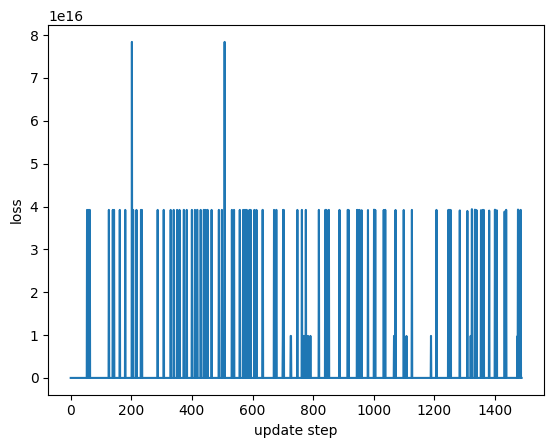

In [11]:
import matplotlib.pyplot as plt
plt.plot(losses_white)
plt.xlabel("update step")
plt.ylabel("loss")
plt.show()


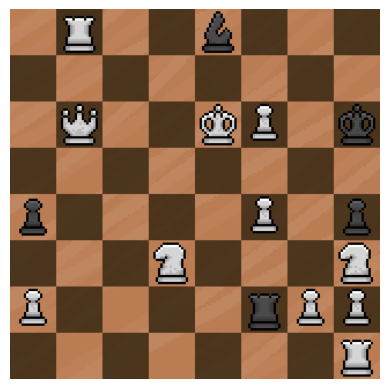

Result: * | moves: 151


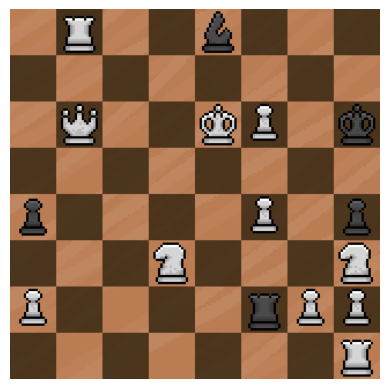

In [13]:
# Play one game: model_1_a (white) vs random (black), show board each move
from IPython.display import clear_output, display

env.reset()
move_count = 0

for agent in env.agent_iter():
    observation, reward, termination, truncation, info = env.last()
    if termination or truncation:
        break

    if agent == "player_0":
        obs_np = np.ascontiguousarray(observation["observation"])
        obs_torch = torch.from_numpy(obs_np).float().permute(2, 0, 1).unsqueeze(0)
        action_mask = torch.from_numpy(observation["action_mask"]).unsqueeze(0)
        with torch.no_grad():
            action = policy(model_1_a, obs_torch, action_mask, eps=0.0)
        env.step(int(action.item()))
    else:
        legal = np.flatnonzero(observation["action_mask"])
        action = int(np.random.choice(legal))
        env.step(action)

    move_count += 1
    frame = env.render()
    clear_output(wait=True)
    plt.imshow(frame)
    plt.axis("off")
    display(plt.gcf())
    if move_count > 150:
      break

result = env.unwrapped.board.result()
print("Result:", result, "| moves:", move_count)


In [433]:
from pettingzoo.classic import chess_v6

env = chess_v6.env(render_mode="human")
env.reset(seed=42)
old_reward = None
reward = 0

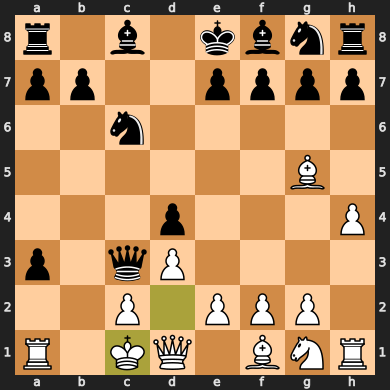

In [31]:
env.unwrapped.board